In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from pathlib import Path

sys.path.append(os.path.abspath('..'))

# importar funções úteis do módulo de preprocessing
from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.utils import *
from src.evaluate import *
from src.monitoring import *

In [2]:
#Parâmetros globais
TARGET_COL = "ALTO_INDE"

NUMERIC_COLS = [
    "IAA", "IEG", "IPS", "IDA", "IPP", "IPV", "IAN",
    "DEFASAGEM", "NOTA_PORT", "NOTA_MAT", "NOTA_ING",
    "ANO_INGRESSO", "QTDE_AVAL"
]

CATEGORICAL_COLS = [
    "FASE", "TURMA"
]

In [3]:
ARTIFACTS_DIR = Path("../artifacts")

model = joblib.load(ARTIFACTS_DIR / "model_v1.joblib")

train_df = pd.read_parquet(ARTIFACTS_DIR / "train_data.parquet")
test_df = pd.read_parquet(ARTIFACTS_DIR / "test_data.parquet")

In [4]:
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

,metric,value
0,accuracy,0.942042
1,precision,1.000000
2,recall,0.906555
3,f1_score,0.950988
4,roc_auc,0.996960


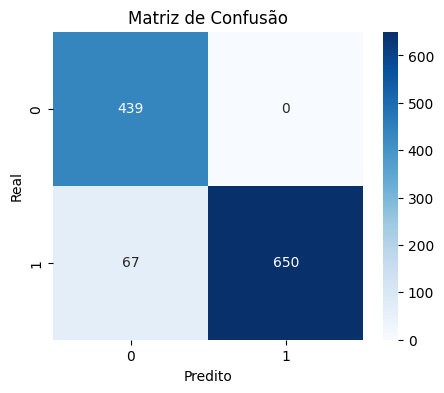

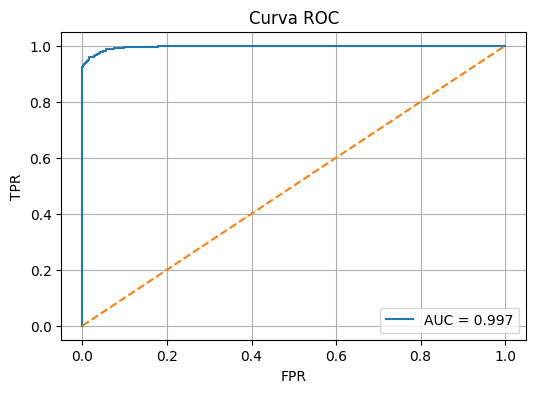

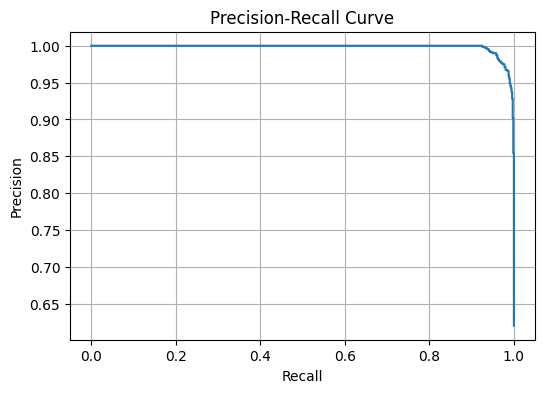

In [5]:
metrics_df, _, metrics_dict = evaluate_model(
    model,
    X_test,
    y_test,
    plot=True
)

metrics_df

In [6]:
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

prediction_drift = detect_prediction_drift(
    pd.Series(train_preds),
    pd.Series(test_preds)
)

prediction_drift

{'train_positive_rate': np.float64(0.580042689434365),
 'new_positive_rate': np.float64(0.5622837370242214),
 'absolute_change': np.float64(0.01775895241014358),
 'drift_detected': np.False_}

In [7]:
numeric_features = NUMERIC_COLS

drift_report = detect_numeric_drift(
    train_df,
    test_df,
    numeric_features
)

drift_report

{'IAA': {'train_mean': np.float64(7.594510672358592),
  'new_mean': np.float64(8.561865916955018),
  'relative_change': np.float64(0.1273755688752532),
  'drift_detected': np.False_},
 'IEG': {'train_mean': np.float64(8.32427961579509),
  'new_mean': np.float64(7.374987581867446),
  'relative_change': np.float64(0.11403892753523823),
  'drift_detected': np.False_},
 'IPS': {'train_mean': np.float64(6.026643543223051),
  'new_mean': np.float64(6.888817041522491),
  'relative_change': np.float64(0.14306028704960733),
  'drift_detected': np.False_},
 'IDA': {'train_mean': np.float64(6.401725364638919),
  'new_mean': np.float64(6.378964821222606),
  'relative_change': np.float64(0.0035553758658031158),
  'drift_detected': np.False_},
 'IPP': {'train_mean': np.float64(7.531511250441835),
  'new_mean': np.float64(7.544041053919551),
  'relative_change': np.float64(0.001663650414560529),
  'drift_detected': np.False_},
 'IPV': {'train_mean': np.float64(7.654539754534686),
  'new_mean': np.flo

In [ ]:
feature = "INDE"

plt.figure(figsize=(6,4))
sns.kdeplot(train_df[feature], label="Train")
sns.kdeplot(test_df[feature], label="Test")
plt.legend()
plt.title(f"Drift - {feature}")
plt.show()